# Chapter 6, Example 4: Kikuchi regions and generalized belief propagation

This notebook uses a $2\times3$ binary grid.  Two overlapping plaquette regions cover the graph:

$$
R_L=\{1,2,4,5\},
\qquad
R_R=\{2,3,5,6\},
\qquad
S=R_L\cap R_R=\{2,5\}.
$$

The region graph $R_L-S-R_R$ is a tree.  Therefore the junction-tree or Kikuchi factorization is exact:

$$
p(\boldsymbol{x})
=\frac{p_{R_L}(\boldsymbol{x}_{R_L})p_{R_R}(\boldsymbol{x}_{R_R})}{p_S(\boldsymbol{x}_S)},
$$

and the entropy satisfies

$$
H(p)=H(p_{R_L})+H(p_{R_R})-H(p_S).
$$

This is the simplest nontrivial example showing why larger regions can repair the loop error of ordinary Bethe inference.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch06":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch06").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch06"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

NODE_COLOR = "#30343b"
NODE_TEXT_COLOR = "white"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def binary_entropy_from_magnetization(m):
    m = np.asarray(m, dtype=float)
    q = np.clip((1.0 + m) / 2.0, 1e-15, 1.0 - 1e-15)
    return -(q * np.log(q) + (1.0 - q) * np.log(1.0 - q))

In [2]:
N = 6
LEFT = (0, 1, 3, 4)
RIGHT = (1, 2, 4, 5)
SEPARATOR = (1, 4)
EDGES = [(0, 1), (1, 2), (3, 4), (4, 5), (0, 3), (1, 4), (2, 5)]
COUPLINGS = {(0, 1): 0.55, (1, 2): -0.35, (3, 4): 0.48, (4, 5): 0.62,
             (0, 3): 0.42, (1, 4): -0.50, (2, 5): 0.38}
FIELDS = np.array([0.08, -0.03, 0.06, -0.05, 0.04, 0.02])
BETA = 1.15
STATES = np.array(list(product([-1, 1], repeat=N)), dtype=int)


def log_weight(state):
    return BETA * (sum(COUPLINGS[e] * state[e[0]] * state[e[1]] for e in EDGES) + np.dot(FIELDS, state))

log_weights = np.array([log_weight(state) for state in STATES])
shift = log_weights.max()
weights = np.exp(log_weights - shift)
probabilities = weights / weights.sum()
log_z_exact = shift + np.log(weights.sum())


def marginal(indices):
    configurations = np.array(list(product([-1, 1], repeat=len(indices))), dtype=int)
    values = np.zeros(len(configurations))
    lookup = {tuple(config): k for k, config in enumerate(configurations)}
    for state, probability in zip(STATES, probabilities):
        values[lookup[tuple(state[list(indices)])]] += probability
    return configurations, values

left_states, p_left = marginal(LEFT)
right_states, p_right = marginal(RIGHT)
separator_states, p_separator = marginal(SEPARATOR)

h_exact = entropy(probabilities)
h_kikuchi = entropy(p_left) + entropy(p_right) - entropy(p_separator)
assert np.isclose(h_exact, h_kikuchi, atol=1e-12)

## Spatial graph and region graph

<>:17: SyntaxWarning: invalid escape sequence '\{'
<>:17: SyntaxWarning: invalid escape sequence '\{'
<>:17: SyntaxWarning: invalid escape sequence '\{'
<>:17: SyntaxWarning: invalid escape sequence '\{'
<>:17: SyntaxWarning: invalid escape sequence '\{'
<>:17: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_1666/693150384.py:17: SyntaxWarning: invalid escape sequence '\{'
  labels={"R_L": "$R_L$\n$\{1,2,4,5\}$", "S": "$S$\n$\{2,5\}$", "R_R": "$R_R$\n$\{2,3,5,6\}$"},
/tmp/ipykernel_1666/693150384.py:17: SyntaxWarning: invalid escape sequence '\{'
  labels={"R_L": "$R_L$\n$\{1,2,4,5\}$", "S": "$S$\n$\{2,5\}$", "R_R": "$R_R$\n$\{2,3,5,6\}$"},
/tmp/ipykernel_1666/693150384.py:17: SyntaxWarning: invalid escape sequence '\{'
  labels={"R_L": "$R_L$\n$\{1,2,4,5\}$", "S": "$S$\n$\{2,5\}$", "R_R": "$R_R$\n$\{2,3,5,6\}$"},


Saved: figs/ch06_04_grid_and_region_graph.pdf


Saved: figs/ch06_04_grid_and_region_graph.png


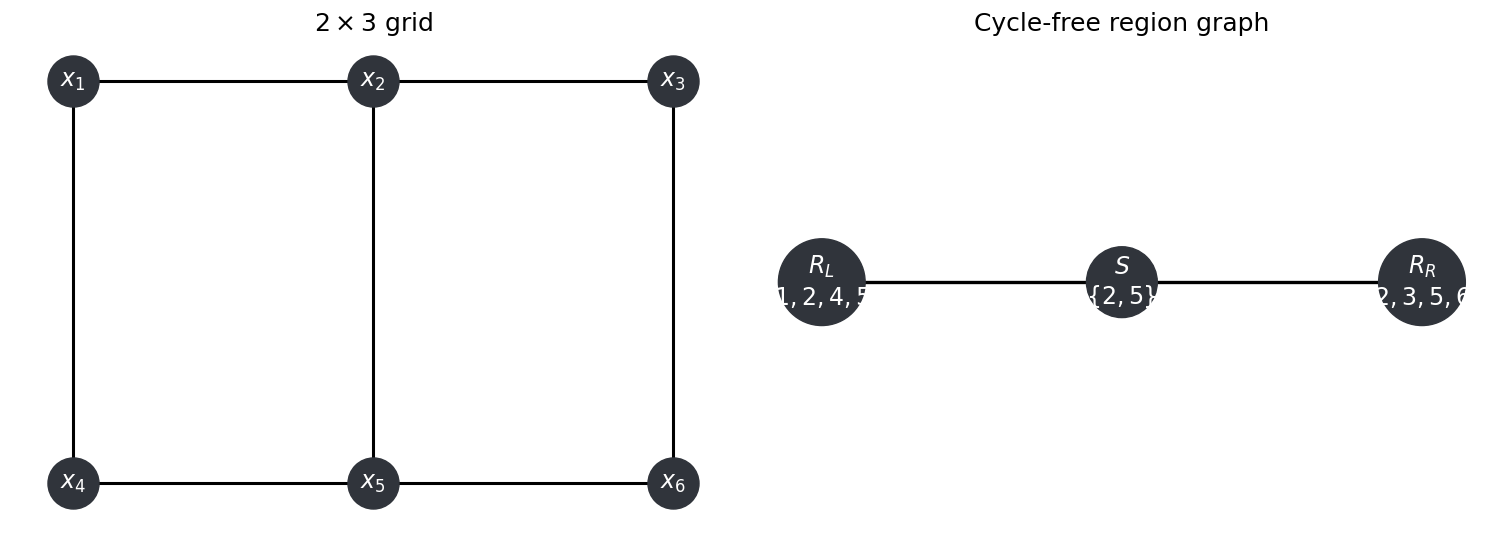

In [3]:
spatial = nx.Graph(EDGES)
spatial_pos = {0: (0, 1), 1: (1, 1), 2: (2, 1), 3: (0, 0), 4: (1, 0), 5: (2, 0)}
region_graph = nx.Graph()
region_graph.add_edges_from([("R_L", "S"), ("S", "R_R")])
region_pos = {"R_L": (0, 0), "S": (1.8, 0), "R_R": (3.6, 0)}

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.6))
nx.draw_networkx_nodes(spatial, spatial_pos, node_size=1350, node_color=NODE_COLOR, ax=axes[0])
nx.draw_networkx_labels(spatial, spatial_pos, labels={i: rf"$x_{i+1}$" for i in range(N)},
                        font_size=17, font_color=NODE_TEXT_COLOR, ax=axes[0])
nx.draw_networkx_edges(spatial, spatial_pos, width=2.2, ax=axes[0])
axes[0].set_title(r"$2\times3$ grid")
axes[0].axis("off")

nx.draw_networkx_nodes(region_graph, region_pos, node_size=[3900, 2600, 3900], node_color=NODE_COLOR, ax=axes[1])
nx.draw_networkx_labels(region_graph, region_pos,
    labels={"R_L": "$R_L$\n$\{1,2,4,5\}$", "S": "$S$\n$\{2,5\}$", "R_R": "$R_R$\n$\{2,3,5,6\}$"},
    font_size=17, font_color=NODE_TEXT_COLOR, ax=axes[1])
nx.draw_networkx_edges(region_graph, region_pos, width=2.4, ax=axes[1])
axes[1].set_title("Cycle-free region graph")
axes[1].axis("off")
fig.tight_layout()
save_figure(fig, "ch06_04_grid_and_region_graph")
plt.show()

## Exact Kikuchi entropy counting

Saved: figs/ch06_04_kikuchi_entropy.pdf


Saved: figs/ch06_04_kikuchi_entropy.png


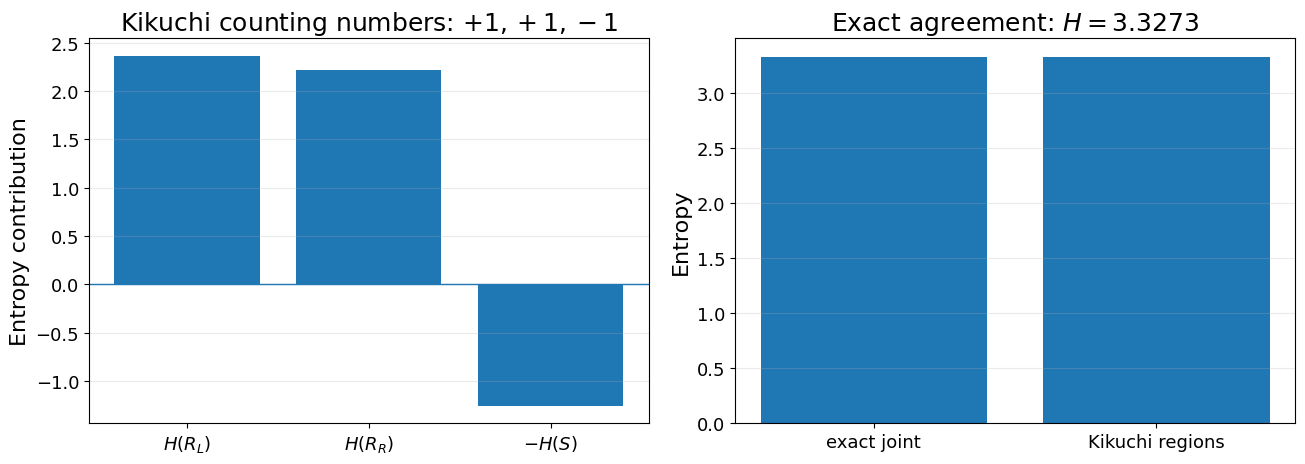

In [4]:
components = pd.Series({
    r"$H(R_L)$": entropy(p_left),
    r"$H(R_R)$": entropy(p_right),
    r"$-H(S)$": -entropy(p_separator),
})

fig, axes = plt.subplots(1, 2, figsize=(13.3, 4.9))
axes[0].bar(components.index, components.values)
axes[0].axhline(0, linewidth=1)
axes[0].set_ylabel("Entropy contribution")
axes[0].set_title("Kikuchi counting numbers: $+1,+1,-1$")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(["exact joint", "Kikuchi regions"], [h_exact, h_kikuchi])
axes[1].set_ylabel("Entropy")
axes[1].set_title(rf"Exact agreement: $H={h_exact:.4f}$")
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch06_04_kikuchi_entropy")
plt.show()

## Exact region-to-region message passing

Saved: figs/ch06_04_region_messages.pdf


Saved: figs/ch06_04_region_messages.png


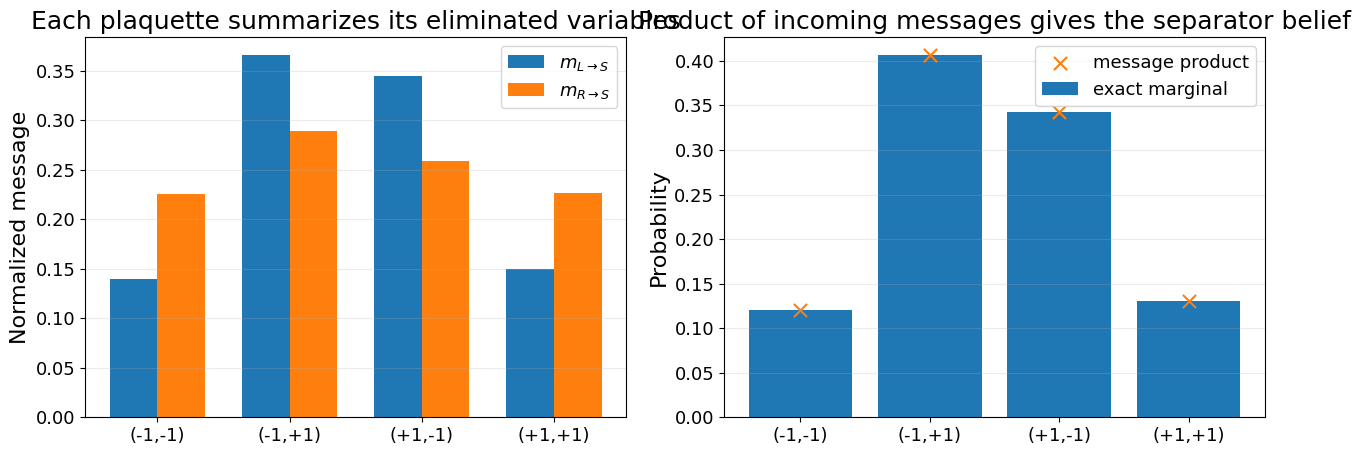

In [5]:
# Assign each original factor to exactly one maximal region.
left_edges = [(0, 1), (3, 4), (0, 3), (1, 4)]
right_edges = [(1, 2), (4, 5), (2, 5)]
left_fields = [0, 1, 3, 4]
right_fields = [2, 5]

left_configurations = np.array(list(product([-1, 1], repeat=len(LEFT))), dtype=int)
right_configurations = np.array(list(product([-1, 1], repeat=len(RIGHT))), dtype=int)
separator_configurations = np.array(list(product([-1, 1], repeat=len(SEPARATOR))), dtype=int)
left_index = {node: k for k, node in enumerate(LEFT)}
right_index = {node: k for k, node in enumerate(RIGHT)}
separator_lookup = {tuple(config): k for k, config in enumerate(separator_configurations)}

psi_left = np.array([
    np.exp(BETA * (
        sum(COUPLINGS[e] * config[left_index[e[0]]] * config[left_index[e[1]]] for e in left_edges)
        + sum(FIELDS[i] * config[left_index[i]] for i in left_fields)
    ))
    for config in left_configurations
])
psi_right = np.array([
    np.exp(BETA * (
        sum(COUPLINGS[e] * config[right_index[e[0]]] * config[right_index[e[1]]] for e in right_edges)
        + sum(FIELDS[i] * config[right_index[i]] for i in right_fields)
    ))
    for config in right_configurations
])

message_left = np.zeros(len(separator_configurations))
message_right = np.zeros(len(separator_configurations))
for config, value in zip(left_configurations, psi_left):
    key = tuple(config[[left_index[i] for i in SEPARATOR]])
    message_left[separator_lookup[key]] += value
for config, value in zip(right_configurations, psi_right):
    key = tuple(config[[right_index[i] for i in SEPARATOR]])
    message_right[separator_lookup[key]] += value

z_regions = np.dot(message_left, message_right)
assert np.isclose(np.log(z_regions), log_z_exact, atol=1e-11)
separator_from_messages = message_left * message_right / z_regions
assert np.max(np.abs(separator_from_messages - p_separator)) < 1e-11

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
x = np.arange(len(separator_configurations))
labels = [f"({a:+d},{b:+d})" for a, b in separator_configurations]
axes[0].bar(x - 0.18, message_left / message_left.sum(), 0.36, label=r"$m_{L\to S}$")
axes[0].bar(x + 0.18, message_right / message_right.sum(), 0.36, label=r"$m_{R\to S}$")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("Normalized message")
axes[0].set_title("Each plaquette summarizes its eliminated variables")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x, p_separator, label="exact marginal")
axes[1].scatter(x, separator_from_messages, marker="x", s=90, label="message product")
axes[1].set_xticks(x, labels)
axes[1].set_ylabel("Probability")
axes[1].set_title("Product of incoming messages gives the separator belief")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch06_04_region_messages")
plt.show()

## Exercises

1. **Basic.** Verify the region marginal consistency conditions between $R_L$, $R_R$, and $S$.
2. **Extension.** Move the shared vertical-edge factor from $R_L$ to $R_R$.  Confirm that the global distribution and $Z$ are unchanged.
3. **Approximation.** Add a diagonal edge $(1,6)$ that is not contained in either plaquette.  Propose an enlarged region graph and compare its complexity.
4. **Research.** Extend the grid to $2\times4$ with three overlapping plaquettes.  Implement exact parent-to-child region messages and verify the junction-tree entropy formula.